In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from fastdtw import fastdtw
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn import preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from tslearn.metrics import cdist_dtw
from tslearn.barycenters import dtw_barycenter_averaging
from sklearn.metrics import calinski_harabasz_score

c:\Users\lukma\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tslearn\bases\bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [2]:
# Load dynamic data

order_data_path = "D:\\ITB\\Thesis\\Preprocessing\\訂單資料_order.csv"
df_order = pd.read_csv(order_data_path, encoding = 'utf-8-sig', sep=';', decimal=',')
df_order.info()

<class 'pandas.DataFrame'>
RangeIndex: 250657 entries, 0 to 250656
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   订单号              250657 non-null  str    
 1   商品编码             250657 non-null  int64  
 2   商品名称             250657 non-null  str    
 3   商品数量             250657 non-null  int64  
 4   创建时间             250657 non-null  str    
 5   price_per_piece  250657 non-null  float64
 6   sales            250657 non-null  float64
dtypes: float64(2), int64(2), str(3)
memory usage: 13.4 MB


In [3]:
df_order.head()

,订单号,商品编码,商品名称,商品数量,创建时间,price_per_piece,sales
0,DO_0000263618,10000005001,可口可樂330ml,6,01/08/2021 00:57,13.833333,83.0
1,DO_0000263618,10002014001,維大力汽水Can330ml,6,01/08/2021 00:57,13.666667,82.0
2,DO_0000263618,10002018001,黑松沙士330ml,24,01/08/2021 00:57,13.833333,332.0
3,DO_0000263618,10014037001,好聖地100椰子水 350ml,3,01/08/2021 00:57,29.666667,89.0
4,DO_0000263618,10020007001,伯朗咖啡原味Can240ml:金車伯朗咖啡,24,01/08/2021 00:57,20.916667,502.0


In [4]:
# Reshape order data

# Build per-product weekly time series matrix
df_order['创建时间'] = pd.to_datetime(df_order['创建时间'], format='%d/%m/%Y %H:%M')    

# Group the sales data by product and week, and calculate the total sales for each product for each week
    # Build week-start timestamp (Monday)
df_order['week_start'] = df_order['创建时间'].dt.to_period('W-MON').dt.start_time

    # Aggregate weekly sales per product
weekly_sales = df_order.groupby(['week_start', '商品名称', '商品编码'], as_index = False)['商品数量'].sum()

# Wide matrix: rows are products, columns are weeks, values are sales
ts_wide = weekly_sales.pivot(index=['商品名称', '商品编码'], 
                             columns=['week_start'], 
                             values='商品数量').fillna(0.0).sort_index(axis=1)
ts_wide.head()

,week_start,2021-07-27,2021-08-03,2021-08-10,2021-08-17
商品名称,商品编码,,,,
(平)Shell 機油 10W40 4T:殼牌10W40,35751021001,0.0,4.0,2.0,3.0
(平)Shell Ultra 5W40 全合成機油:5W40 全合成機,35300004001,0.0,4.0,8.0,4.0
100紫色蔬果汁TP250ml:100紫色蔬果汁,10010007001,0.0,0.0,0.0,36.0
11孔透明文件套100入,32500008001,0.0,1.0,19.0,16.0
1881純棉素色毛巾4入:33x76公分,65106030001,1.0,17.0,35.0,14.0


In [5]:
ts_wide.info()

<class 'pandas.DataFrame'>
MultiIndex: 4802 entries, ('(平)Shell  機油 10W40 4T:殼牌10W40', np.int64(35751021001)) to ('龜甲萬醬油膏490ml', np.int64(14621045001))
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   2021-07-27 00:00:00  4802 non-null   float64
 1   2021-08-03 00:00:00  4802 non-null   float64
 2   2021-08-10 00:00:00  4802 non-null   float64
 3   2021-08-17 00:00:00  4802 non-null   float64
dtypes: float64(4)
memory usage: 243.8+ KB


Elbow table:
     k         sse
0    2  142.759307
1    3   92.052885
2    4   59.364453
3    5   44.012740
4    6   33.713470
5    7   24.447562
6    8   20.103744
7    9   16.939595
8   10   14.255960
9   11   12.464855
10  12   10.778874
11  13    9.498557
12  14    8.221542
13  15    7.147380
14  16    6.381608
15  17    5.686142
16  18    5.016254
17  19    4.437123

Best k by elbow: 7


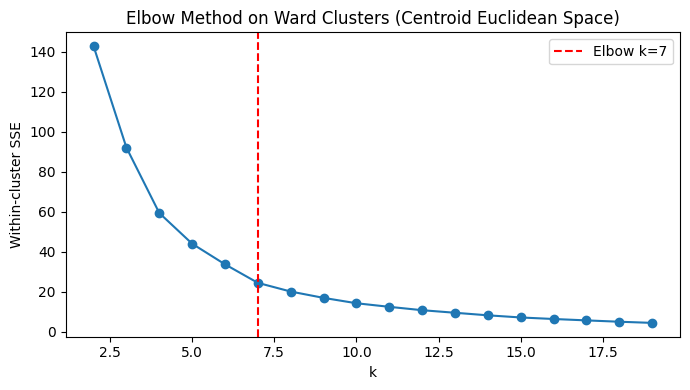

In [6]:
# Dynamic clustering

# Function to calculate Dunn Index

def dunn_index(D, labels):
    clusters = np.unique(labels)

    intra = []
    for c in clusters:
        idx = np.where(labels == c)[0]
        if len(idx) > 1:
            intra.append(np.max(D[np.ix_(idx, idx)]))

    if len(intra) == 0:
        return 0.0

    max_intra = np.max(intra)

    inter = []
    for i, c1 in enumerate(clusters):
        idx1 = np.where(labels == c1)[0]
        for c2 in clusters[i+1:]:
            idx2 = np.where(labels == c2)[0]
            inter.append(np.min(D[np.ix_(idx1, idx2)]))

    if len(inter) == 0:
        return 0.0

    min_inter = np.min(inter)

    return min_inter / max_intra


# Stage 1: Cheap DTW grouping via MiniBatchKMeans

X = ts_wide.to_numpy(dtype=float)
n_series = X.shape[0]
n_prototypes = int(np.sqrt(n_series))

prototype_model = MiniBatchKMeans(n_clusters=n_prototypes, 
                                   random_state=42,
                                   batch_size=2048,
                                   n_init = 10,
                                   )
prototype_labels = prototype_model.fit_predict(X)

# Stage 2: DBA centroid per prototype group
centroids = []
group_ids = [] # prototype label for each centroid

for p in range (n_prototypes): 
    idx = np.where(prototype_labels == p)[0]
    if len(idx) == 0:
        continue
    
    Xi_3d = X[idx, :, np.newaxis]
    centroid = dtw_barycenter_averaging(Xi_3d, max_iter=10)
    centroids.append(centroid[:, 0]) # remove the extra dimension
    group_ids.append(p)
    
C = np.vstack(centroids)
m = C.shape[0]

# Z-normalize each centroid
Cz = (C - C.mean(axis=1, keepdims=True)) / (C.std(axis=1, keepdims=True) + 1e-8) # add small constant to avoid division by zero

# DTW distances matrix between centorids only between prototypes
D_prototype = cdist_dtw(Cz)

# Stage 3: Ward merge on normalized centroid vectors (Euclidean distance)
Z_proto_best = linkage(Cz, method='ward', metric='euclidean')

# Stage 4: choose k by elbow on within-cluster SSE (Ward/Euclidean space)
# The “elbow” is the point where adding clusters stops giving meaningful improvement

def within_cluster_sse(X, labels):
    sse = 0.0
    for c in np.unique(labels):
        Xc = X[labels == c]
        mu = Xc.mean(axis=0, keepdims=True)
        sse += ((Xc - mu) ** 2).sum()
    return sse

# candidate k range
k_candidate = range(2, min(20, m)) 

elbow_rows = []
for k in k_candidate:
    labels_k = fcluster(Z_proto_best, t=k, criterion='maxclust')
    sse_k = within_cluster_sse(Cz, labels_k)
    elbow_rows.append({'k': k, 'sse': sse_k})

df_elbow = pd.DataFrame(elbow_rows)

# automatic elbow: max distance to line between first and last point
x = df_elbow['k'].to_numpy(dtype=float)
y = df_elbow['sse'].to_numpy(dtype=float)

x_n = (x - x.min()) / (x.max() - x.min() + 1e-12)
y_n = (y - y.min()) / (y.max() - y.min() + 1e-12)

p1 = np.array([x_n[0], y_n[0]])
p2 = np.array([x_n[-1], y_n[-1]])

num = np.abs((p2[1] - p1[1]) * x_n - (p2[0] - p1[0]) * y_n + p2[0] * p1[1] - p2[1] * p1[0])
den = np.sqrt((p2[1] - p1[1])**2 + (p2[0] - p1[0])**2) + 1e-12
dist_to_line = num / den

best_idx = np.argmax(dist_to_line)
best_k = int(x[best_idx])

print("Elbow table:")
print(df_elbow)
print(f"\nBest k by elbow: {best_k}")

# Plot
plt.figure(figsize=(7, 4))
plt.plot(df_elbow['k'], df_elbow['sse'], marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Elbow k={best_k}')
plt.title('Elbow Method on Ward Clusters (Centroid Euclidean Space)')
plt.xlabel('k')
plt.ylabel('Within-cluster SSE')
plt.legend()
plt.tight_layout()
plt.show()

# Final labels with elbow-selected k
centroid_labels = fcluster(Z_proto_best, t=best_k, criterion='maxclust')

In [7]:
# Performance Evaluation

# DTW: Silhoutte, Dunn
# Euclidean: DB, CH
 
k_candidate = range(2, min(10, m // 2))
validity_result = []

for k in k_candidate:
    proto_labels_k = fcluster(Z_proto_best, t=k, criterion='maxclust')
    # Performance evaluation
    sil = silhouette_score(D_prototype, proto_labels_k, metric='precomputed')
    dunn = dunn_index(D_prototype, proto_labels_k)
    
    db = davies_bouldin_score(Cz, proto_labels_k)
    ch = calinski_harabasz_score(Cz, proto_labels_k)
    
    validity_result.append({
        'k': k, 
        'silhouette': sil,
        'dunn': dunn,
        'davies_bouldin': db,
        'calinski_harabasz': ch
    })
    
df_proto_validity = pd.DataFrame(validity_result)

print("Prototype-level validity indices:")
print(df_proto_validity)

Prototype-level validity indices:
   k  silhouette      dunn  davies_bouldin  calinski_harabasz
0  2    0.095859  0.018516        1.225273          31.656437
1  3    0.188666  0.018516        1.074488          42.358387
2  4    0.256672  0.024986        0.675891          55.055470
3  5    0.263994  0.027488        0.705162          60.418169
4  6    0.278979  0.031699        0.693433          65.963739
5  7    0.328330  0.032891        0.632022          78.517180
6  8    0.342507  0.032891        0.659685          82.404916
7  9    0.349955  0.043473        0.646689          85.570767


In [8]:
# Map each product to its prototype cluster via its assigned prototype

group_to_dynamic = {gid: int(centroid_labels[i]) for i, gid in enumerate(group_ids)}

dynamic_cluster_labels = np.array([group_to_dynamic[prototype_labels[prod_idx]] for prod_idx in range(len(prototype_labels))])
ts_wide['dynamic_cluster'] = dynamic_cluster_labels

print(f'Dynamic cluster distribution:')  
print(ts_wide['dynamic_cluster'].value_counts().sort_index())

Dynamic cluster distribution:
dynamic_cluster
1     695
2    1613
3     684
4     796
5     161
6     265
7     588
Name: count, dtype: int64


In [28]:
# Save the dynamic cluster assignment to CSV
path_save = "D:/ITB/Thesis/Clustering/dynamic_cluster_results.csv"
df_order.to_csv(path_save, index=False, encoding='utf-8-sig', sep=';', decimal=',')

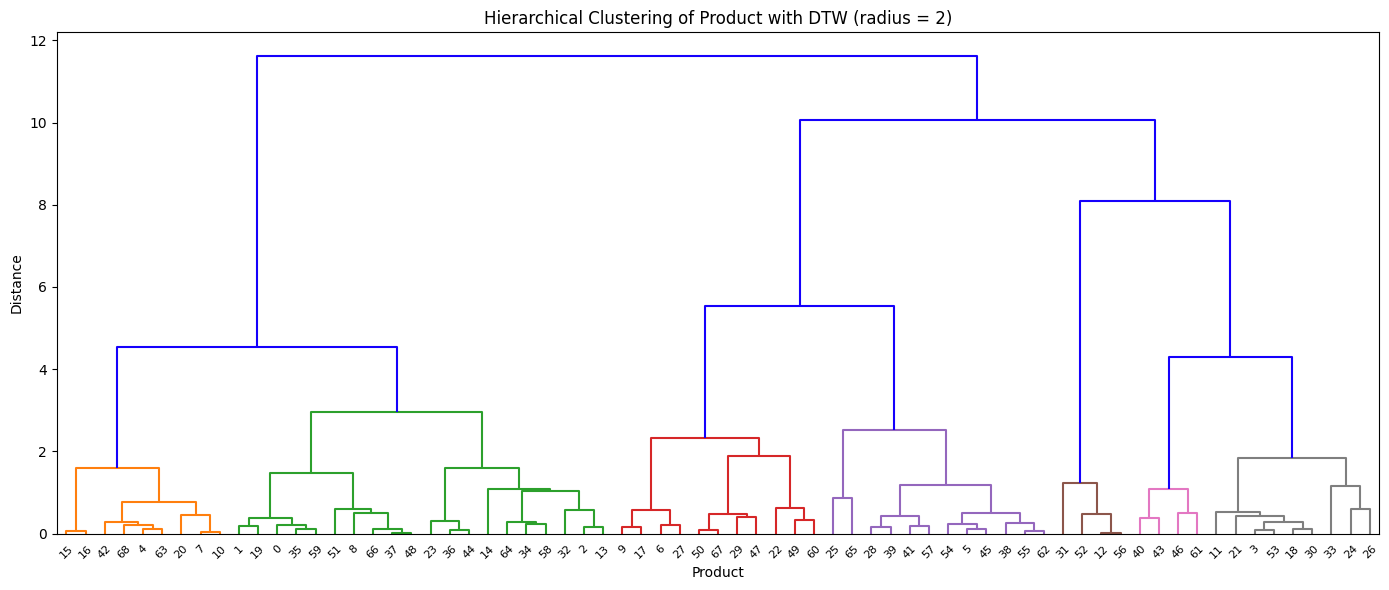

In [ ]:
# Visualize the Hierarchical Clustering with DTW using Dendogram
product_names = ts_wide.index.get_level_values('商品名称').tolist()

plt.figure(figsize=(14, 6))
dendrogram(Z_proto_best, 
           leaf_rotation=45, 
           leaf_font_size=8,
           above_threshold_color='#1500fc', 
           color_threshold=0.3 * np.max(Z_proto_best[:, 2]),  
           )
plt.title('Hierarchical Clustering of Product with DTW (radius = 2)')
plt.xlabel('Product')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

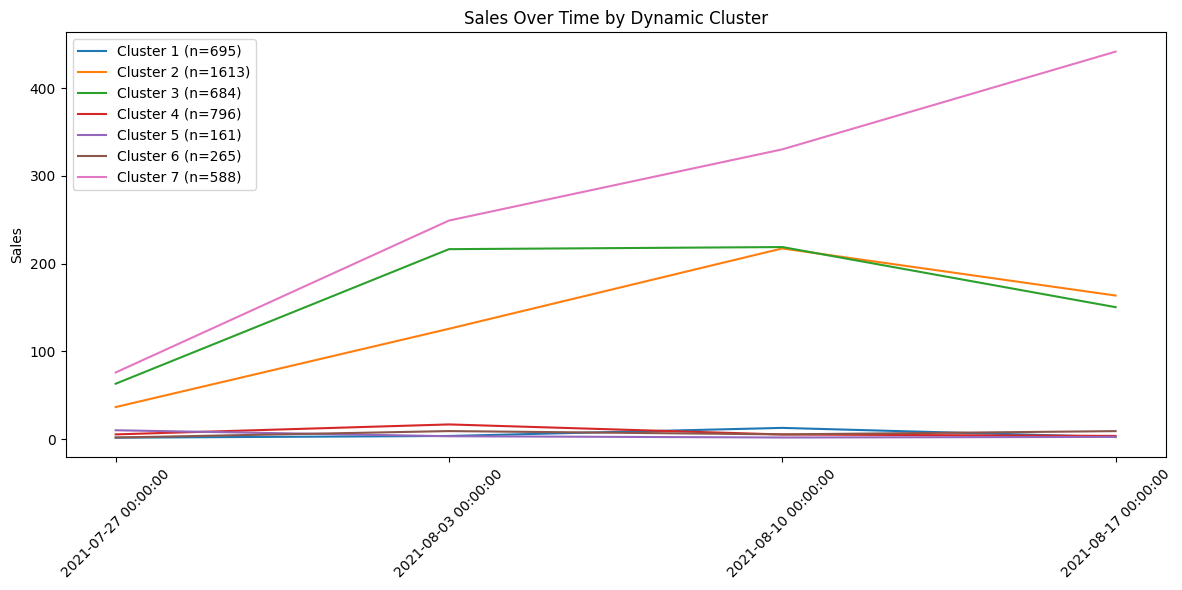

In [10]:
# Visualize the sales time series for each dynamic cluster
ts_matrix = ts_wide.drop(columns=['dynamic_cluster'])
weeks = ts_matrix.columns.astype(str)
best_k = int(best_k)

fig, ax = plt.subplots(figsize=(12,6))

for cluster_id in range(1, best_k + 1):
    mask = ts_wide['dynamic_cluster'] == cluster_id
    cluster_ts = ts_matrix[mask]

    n_products = mask.sum()
    mean_sales = cluster_ts.mean(axis=0)
    std_sales = cluster_ts.std(axis=0)

    x = range(len(weeks))

    ax.plot(x, mean_sales, label=f'Cluster {cluster_id} (n={n_products})')

ax.set_title("Sales Over Time by Dynamic Cluster")
ax.set_ylabel("Sales")

ax.set_xticks(range(0, len(weeks), max(1, len(weeks)//12)))
ax.set_xticklabels(
    [weeks[i] for i in range(0, len(weeks), max(1, len(weeks)//12))],
    rotation=45
)

ax.legend()
plt.tight_layout()

In [11]:
# Load the static data
df = pd.read_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_日用生活_weight.csv", sep=';', encoding='utf-8')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   title                     374 non-null    str    
 1   category                  374 non-null    str    
 2   price                     374 non-null    int64  
 3   brand                     370 non-null    str    
 4   specification             374 non-null    str    
 5   query                     374 non-null    str    
 6   original_price            374 non-null    int64  
 7   original_price_checked    374 non-null    int64  
 8   capacity                  374 non-null    float64
 9   shelf_life                374 non-null    float64
 10  order                     374 non-null    int64  
 11  Discount                  374 non-null    str    
 12  Promo                     374 non-null    int64  
 13  _query_key                374 non-null    str    
 14  item_code            

In [12]:
# Incorporate the resultant dynamic cluster labels into the static dataframe
cluster_map = dict(zip(ts_wide.index.get_level_values('商品编码'),ts_wide['dynamic_cluster']))
df['dynamic_cluster'] = df['item_code'].map(cluster_map)

# One-hot encode the dynamic cluster labels
df_encoded = pd.get_dummies(df, columns = ['dynamic_cluster'],prefix='cluster', dtype=int)
df_encoded.head()

,title,category,price,brand,specification,query,original_price,original_price_checked,capacity,shelf_life,...,capacity_category,shelf_life_unit,capacity_normalized,cluster_1.0,cluster_2.0,cluster_3.0,cluster_4.0,cluster_5.0,cluster_6.0,cluster_7.0
0,香滿室薰衣草地板清潔劑補充包,日用生活,85,毛寶,規格：1800g克x1x1bottle瓶,香滿室茶樹地板清潔劑補充包,95,1,1800.0,33.3,...,weight,月,0.287544,0,1,0,0,0,0,0
1,香滿室薰衣草地板清潔劑補充包,日用生活,85,毛寶,規格：1800g克x1x1bottle瓶,香滿室薰衣草地板清潔劑補充包,95,1,1800.0,33.3,...,weight,月,0.287544,0,1,0,0,0,0,0
2,白帥帥防蟑地板清潔劑-2000g,日用生活,169,白帥帥,規格：2000g克x1x1bottle瓶,白帥帥防蟑地板清潔劑,0,1,2000.0,33.3,...,weight,月,0.439714,0,0,0,0,0,1,0
3,毛寶香滿室檀木馨香地板清潔劑,日用生活,109,毛寶,規格：2000g克x1x1bottle瓶,毛寶香滿室檀木馨香地板清潔劑,0,1,2000.0,33.3,...,weight,月,0.439714,0,0,0,1,0,0,0
4,毛寶香滿室海洋微風清潔補充包,日用生活,85,毛寶,規格：1800g克x1x1bag袋,毛寶香滿室海洋微風地板清潔劑,95,1,1800.0,33.3,...,weight,月,0.287544,0,0,0,1,0,0,0


In [13]:
# Normalization of numeric features

# Log-transform skewed price columns
price_columns = ['price_per_piece', 'original_price_per_piece']

for price in price_columns: 
    df_encoded[price] = pd.to_numeric(df_encoded[price])
    df_encoded[f'log_{price}'] = np.log1p(df_encoded[price])

# Columns to normalize
cluster_cols = df_encoded.filter(like='cluster_').columns

cols_to_normalize = list(['estimation_discount', 
                         'log_price_per_piece', 
                         'log_original_price_per_piece', 
                         'shelf_life',
                         'capacity']) + list(cluster_cols)

scaler = StandardScaler()

# Normalize continuous variables
for col in cols_to_normalize:
    df_encoded[f'{col}_normalized'] = scaler.fit_transform(df_encoded[[col]])
df_encoded.head(5)

,title,category,price,brand,specification,query,original_price,original_price_checked,capacity,shelf_life,...,log_price_per_piece_normalized,log_original_price_per_piece_normalized,shelf_life_normalized,cluster_1.0_normalized,cluster_2.0_normalized,cluster_3.0_normalized,cluster_4.0_normalized,cluster_5.0_normalized,cluster_6.0_normalized,cluster_7.0_normalized
0,香滿室薰衣草地板清潔劑補充包,日用生活,85,毛寶,規格：1800g克x1x1bottle瓶,香滿室茶樹地板清潔劑補充包,95,1,1800.0,33.3,...,0.036356,0.860710,-0.295337,-0.406336,1.789482,-0.369835,-0.471405,-0.197203,-0.224860,-0.336296
1,香滿室薰衣草地板清潔劑補充包,日用生活,85,毛寶,規格：1800g克x1x1bottle瓶,香滿室薰衣草地板清潔劑補充包,95,1,1800.0,33.3,...,0.036356,0.860710,-0.295337,-0.406336,1.789482,-0.369835,-0.471405,-0.197203,-0.224860,-0.336296
2,白帥帥防蟑地板清潔劑-2000g,日用生活,169,白帥帥,規格：2000g克x1x1bottle瓶,白帥帥防蟑地板清潔劑,0,1,2000.0,33.3,...,1.055339,-1.109567,-0.295337,-0.406336,-0.558821,-0.369835,-0.471405,-0.197203,4.447221,-0.336296
3,毛寶香滿室檀木馨香地板清潔劑,日用生活,109,毛寶,規格：2000g克x1x1bottle瓶,毛寶香滿室檀木馨香地板清潔劑,0,1,2000.0,33.3,...,0.404402,-1.109567,-0.295337,-0.406336,-0.558821,-0.369835,2.121320,-0.197203,-0.224860,-0.336296
4,毛寶香滿室海洋微風清潔補充包,日用生活,85,毛寶,規格：1800g克x1x1bag袋,毛寶香滿室海洋微風地板清潔劑,95,1,1800.0,33.3,...,0.036356,0.860710,-0.295337,-0.406336,-0.558821,-0.369835,2.121320,-0.197203,-0.224860,-0.336296


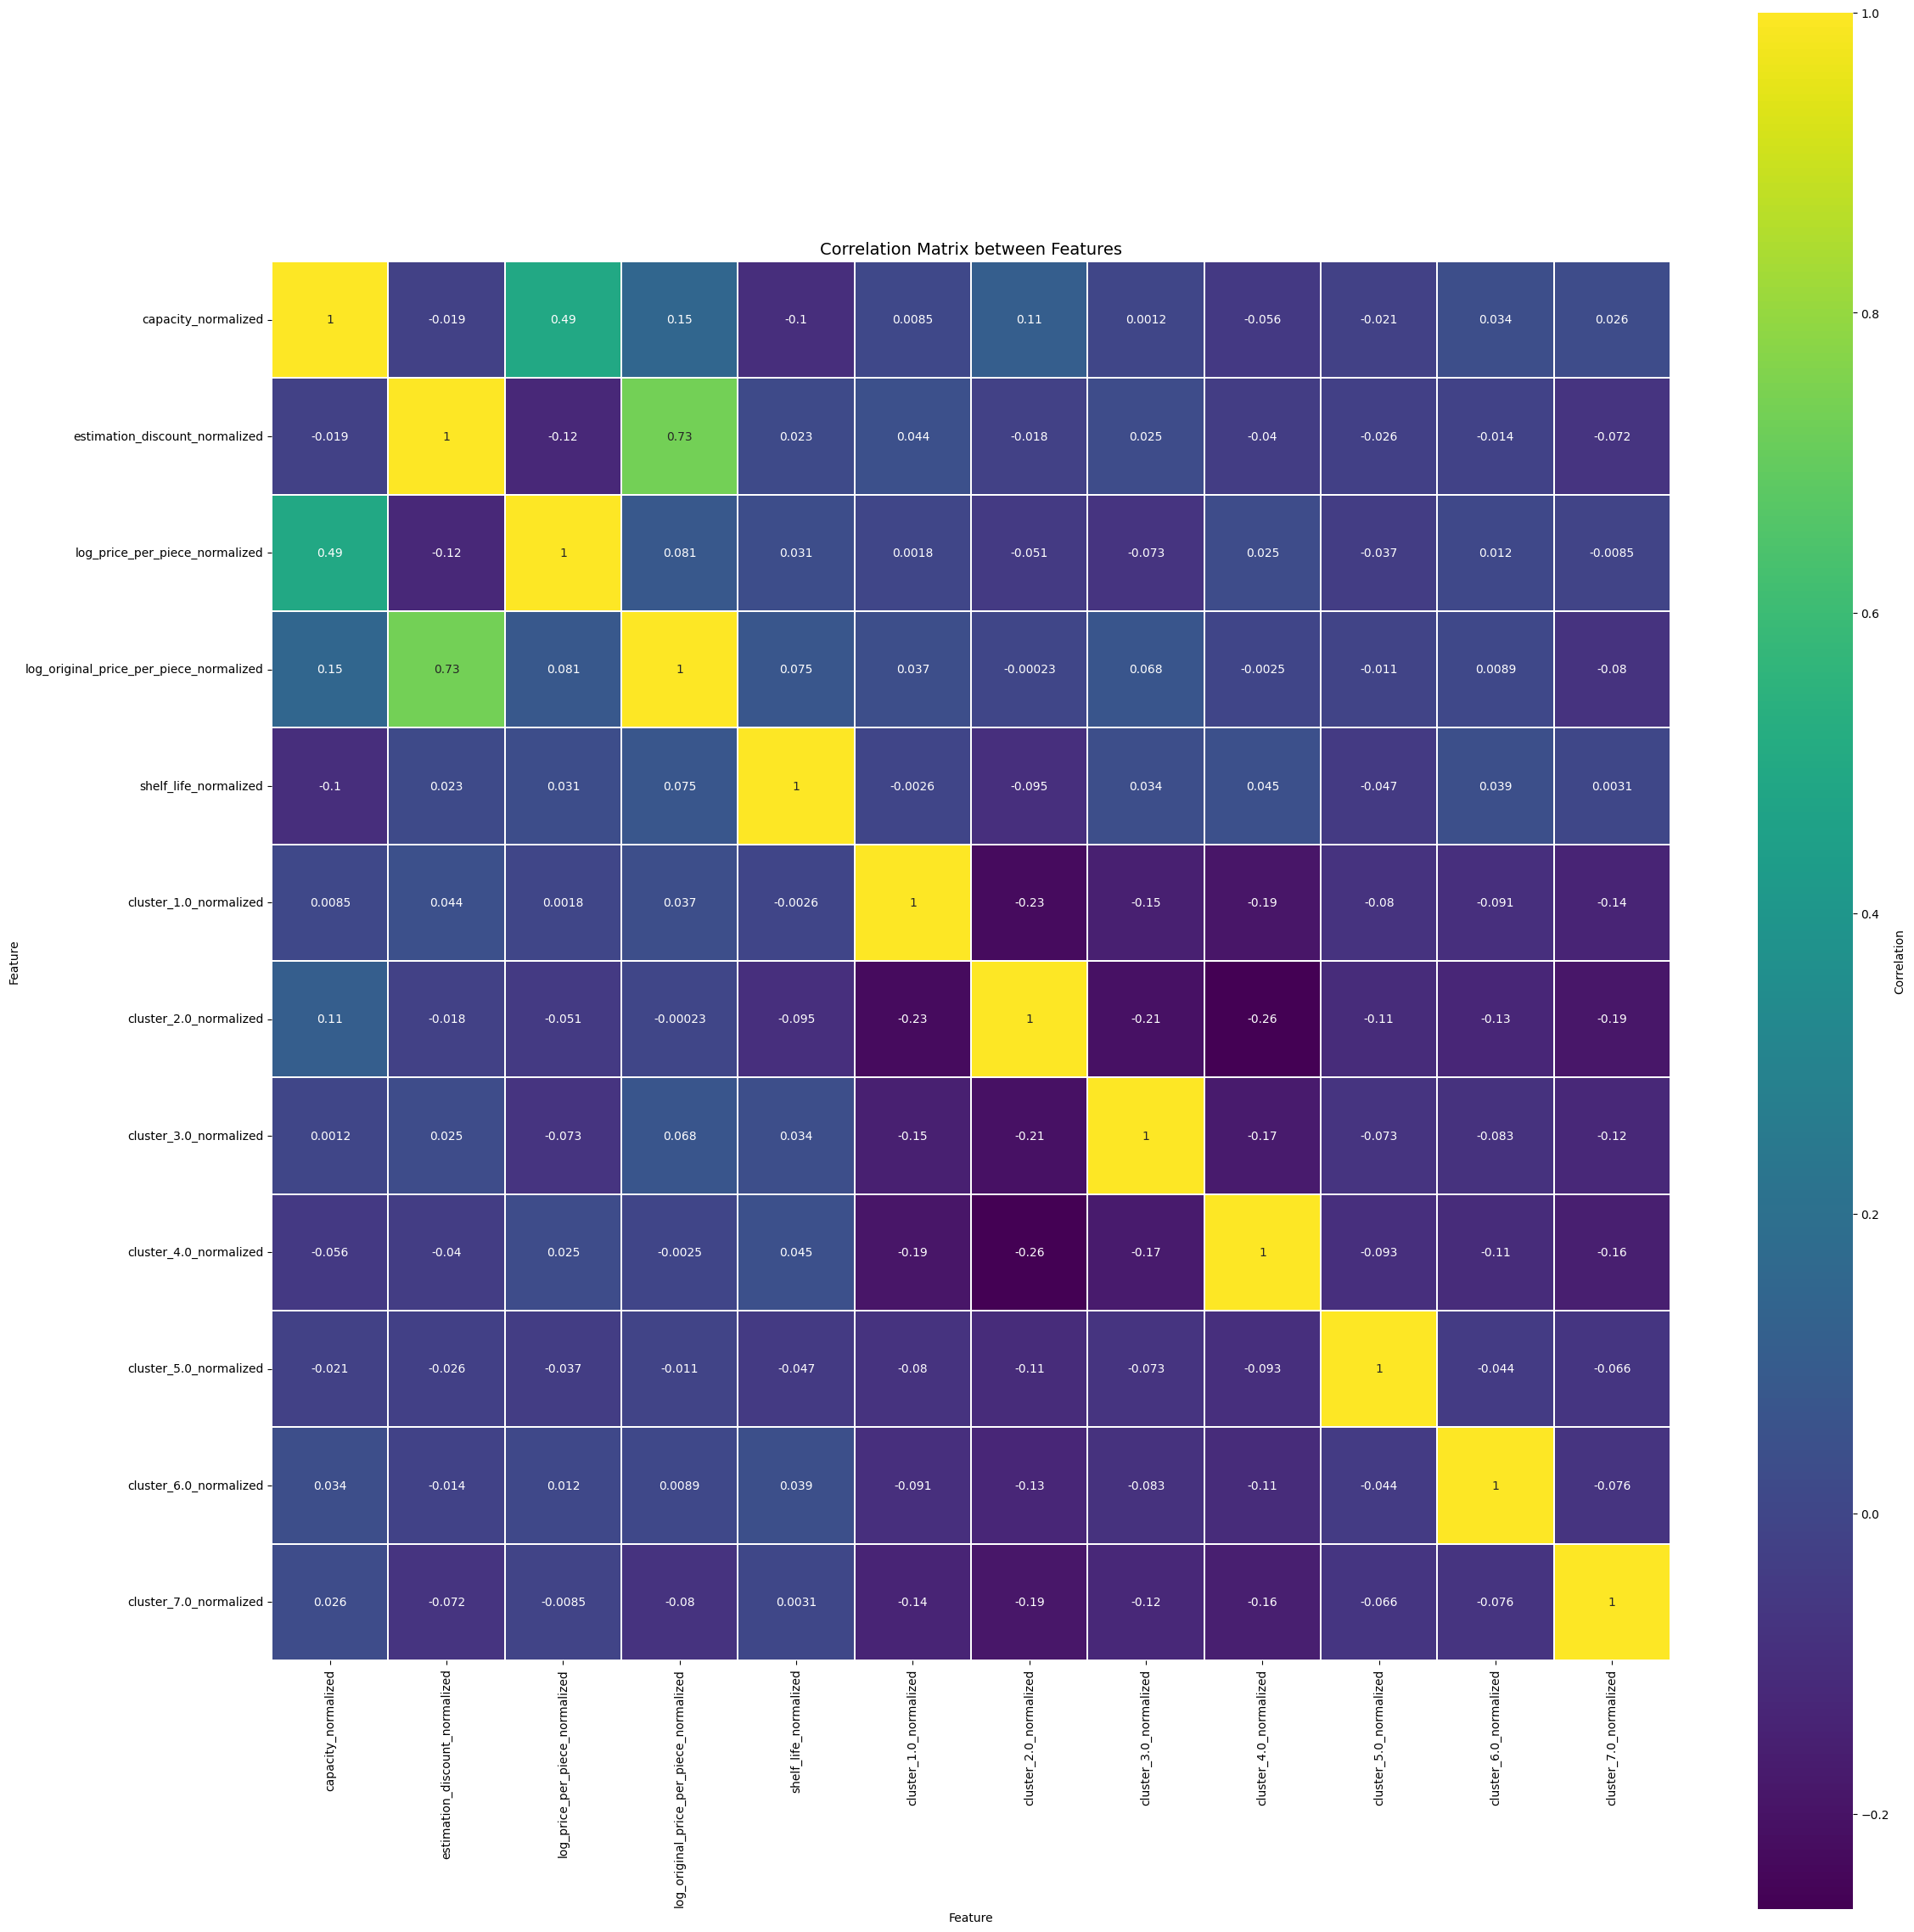

In [14]:
# Correlation matrix to measure the relationship between features using Pearson correlation

features = df_encoded.filter(like='_normalized').columns

rel =  df_encoded[features].corr(method='pearson')
plt.figure(figsize=(24, 24))

sns.heatmap(rel, cmap="viridis", square=True, linewidths=0.3, cbar_kws={"label": "Correlation"}, annot = True)

plt.title("Correlation Matrix between Features", fontsize=14)
plt.xlabel("Feature")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [15]:
# K-means clustering

features_final = df_encoded.filter(like='_normalized').columns.drop('log_price_per_piece_normalized')

# Candidate K values
k_values = list(range(2, 20))

kmeans_clustering_validity = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(df_encoded[features_final])
    labels_k = kmeans.labels_

    cluster_k = df_encoded.copy()
    cluster_k['cluster'] = labels_k

    cluster_sizes = cluster_k['cluster'].value_counts()
    cluster_k['cluster_size'] = cluster_k['cluster'].map(cluster_sizes)
    cluster_k['allocation_type'] = np.where(cluster_k['cluster_size'] > 1,'common allocation','random allocation')

    sil_score = silhouette_score(cluster_k[features_final], cluster_k['cluster'], metric='euclidean')
    db_index = davies_bouldin_score(cluster_k[features_final], cluster_k['cluster'])
    ch_score = calinski_harabasz_score(cluster_k[features_final], cluster_k['cluster'])

    kmeans_clustering_validity.append({
        'k': k,
        'silhouette': sil_score,
        'davies_bouldin': db_index,
        'calinski_harabasz': ch_score,
    })

df_k = pd.DataFrame(kmeans_clustering_validity)

Static K-means elbow table:
   k          sse
0  2  3646.330674
1  3  3227.331154
2  4  2819.288931
3  5  2424.352681
4  6  2042.253229
5  7  1658.595445
6  8  1530.319436
7  9  1339.272755

Best k by elbow: 7


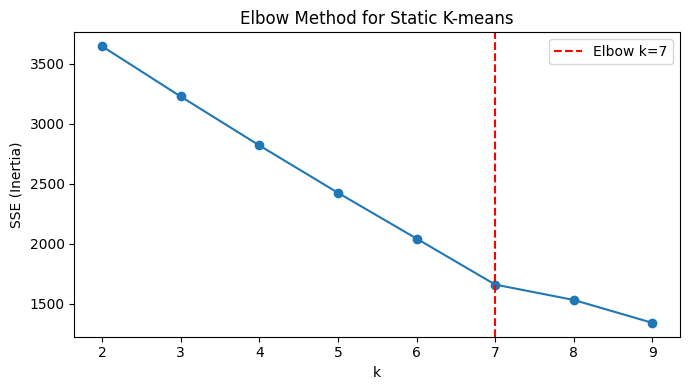

In [16]:
# K-means clustering (static data) with Elbow method

# 1) choose feature matrix
features_final = df_encoded.filter(like='_normalized').columns.drop('log_original_price_per_piece_normalized')
X_static = df_encoded[features_final].astype(float)

# 2) compute inertia (SSE) over candidate k
k_values = list(range(2, 10))
elbow_rows = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X_static)
    elbow_rows.append({
        'k': k,
        'sse': km.inertia_
    })

df_elbow_static = pd.DataFrame(elbow_rows)

# 3) automatic elbow (max distance to line method)
x = df_elbow_static['k'].to_numpy(dtype=float)
y = df_elbow_static['sse'].to_numpy(dtype=float)

x_n = (x - x.min()) / (x.max() - x.min() + 1e-12)
y_n = (y - y.min()) / (y.max() - y.min() + 1e-12)

p1 = np.array([x_n[0], y_n[0]])
p2 = np.array([x_n[-1], y_n[-1]])

num = np.abs((p2[1] - p1[1]) * x_n - (p2[0] - p1[0]) * y_n + p2[0] * p1[1] - p2[1] * p1[0])
den = np.sqrt((p2[1] - p1[1])**2 + (p2[0] - p1[0])**2) + 1e-12
dist_to_line = num / den

best_idx = np.argmax(dist_to_line)
best_k_static = int(x[best_idx])

print("Static K-means elbow table:")
print(df_elbow_static)
print(f"\nBest k by elbow: {best_k_static}")

# 4) elbow plot
plt.figure(figsize=(7, 4))
plt.plot(df_elbow_static['k'], df_elbow_static['sse'], marker='o')
plt.axvline(best_k_static, color='red', linestyle='--', label=f'Elbow k={best_k_static}')
plt.title('Elbow Method for Static K-means')
plt.xlabel('k')
plt.ylabel('SSE (Inertia)')
plt.legend()
plt.tight_layout()
plt.show()

# 5) fit final static model with elbow k
best_kmeans = KMeans(n_clusters=best_k_static, random_state=0, n_init=10)
labels_static = best_kmeans.fit_predict(X_static)

cluster_k_best = df_encoded.copy()
cluster_k_best['cluster'] = labels_static

cluster_sizes_best = cluster_k_best['cluster'].value_counts()
cluster_k_best['cluster_size'] = cluster_k_best['cluster'].map(cluster_sizes_best)
cluster_k_best['allocation_type'] = np.where(
    cluster_k_best['cluster_size'] > 1,
    'common allocation',
    'random allocation'
)

In [17]:
print(df_k)
print(f"Best k: {best_k_static}")

     k  silhouette  davies_bouldin  calinski_harabasz
0    2    0.184314        1.386897          42.041420
1    3    0.195965        1.921478          54.065211
2    4    0.252967        1.811789          53.861936
3    5    0.285014        1.692015          61.181177
4    6    0.341100        1.379768          72.887791
5    7    0.378146        1.113502          89.103298
6    8    0.370809        1.198589          82.641597
7    9    0.377519        1.185810          90.999380
8   10    0.383368        1.135126          89.780647
9   11    0.383994        1.105471          85.947563
10  12    0.396910        1.051336          89.018996
11  13    0.408099        1.015578          90.312286
12  14    0.419253        0.906067          94.058032
13  15    0.412572        0.959197          90.374824
14  16    0.419034        0.954158          91.601351
15  17    0.434511        0.972683          94.087381
16  18    0.435334        0.946642          92.834325
17  19    0.445639        0.

In [18]:
cluster_k_best = pd.DataFrame(cluster_k_best)
cluster_k_best.head()

,title,category,price,brand,specification,query,original_price,original_price_checked,capacity,shelf_life,...,cluster_1.0_normalized,cluster_2.0_normalized,cluster_3.0_normalized,cluster_4.0_normalized,cluster_5.0_normalized,cluster_6.0_normalized,cluster_7.0_normalized,cluster,cluster_size,allocation_type
0,香滿室薰衣草地板清潔劑補充包,日用生活,85,毛寶,規格：1800g克x1x1bottle瓶,香滿室茶樹地板清潔劑補充包,95,1,1800.0,33.3,...,-0.406336,1.789482,-0.369835,-0.471405,-0.197203,-0.224860,-0.336296,6,138,common allocation
1,香滿室薰衣草地板清潔劑補充包,日用生活,85,毛寶,規格：1800g克x1x1bottle瓶,香滿室薰衣草地板清潔劑補充包,95,1,1800.0,33.3,...,-0.406336,1.789482,-0.369835,-0.471405,-0.197203,-0.224860,-0.336296,6,138,common allocation
2,白帥帥防蟑地板清潔劑-2000g,日用生活,169,白帥帥,規格：2000g克x1x1bottle瓶,白帥帥防蟑地板清潔劑,0,1,2000.0,33.3,...,-0.406336,-0.558821,-0.369835,-0.471405,-0.197203,4.447221,-0.336296,2,18,common allocation
3,毛寶香滿室檀木馨香地板清潔劑,日用生活,109,毛寶,規格：2000g克x1x1bottle瓶,毛寶香滿室檀木馨香地板清潔劑,0,1,2000.0,33.3,...,-0.406336,-0.558821,-0.369835,2.121320,-0.197203,-0.224860,-0.336296,1,68,common allocation
4,毛寶香滿室海洋微風清潔補充包,日用生活,85,毛寶,規格：1800g克x1x1bag袋,毛寶香滿室海洋微風地板清潔劑,95,1,1800.0,33.3,...,-0.406336,-0.558821,-0.369835,2.121320,-0.197203,-0.224860,-0.336296,1,68,common allocation


In [ ]:
# Save the final cluster assignment to CSV
path_save = "D:/ITB/Thesis/Clustering/mixed_cluster_results.csv"
cluster_k_best.to_csv(path_save, index=False, decimal=',', sep=';', encoding='utf-8-sig') 

TypeError: NDFrame.to_csv() got an unexpected keyword argument 'engine'

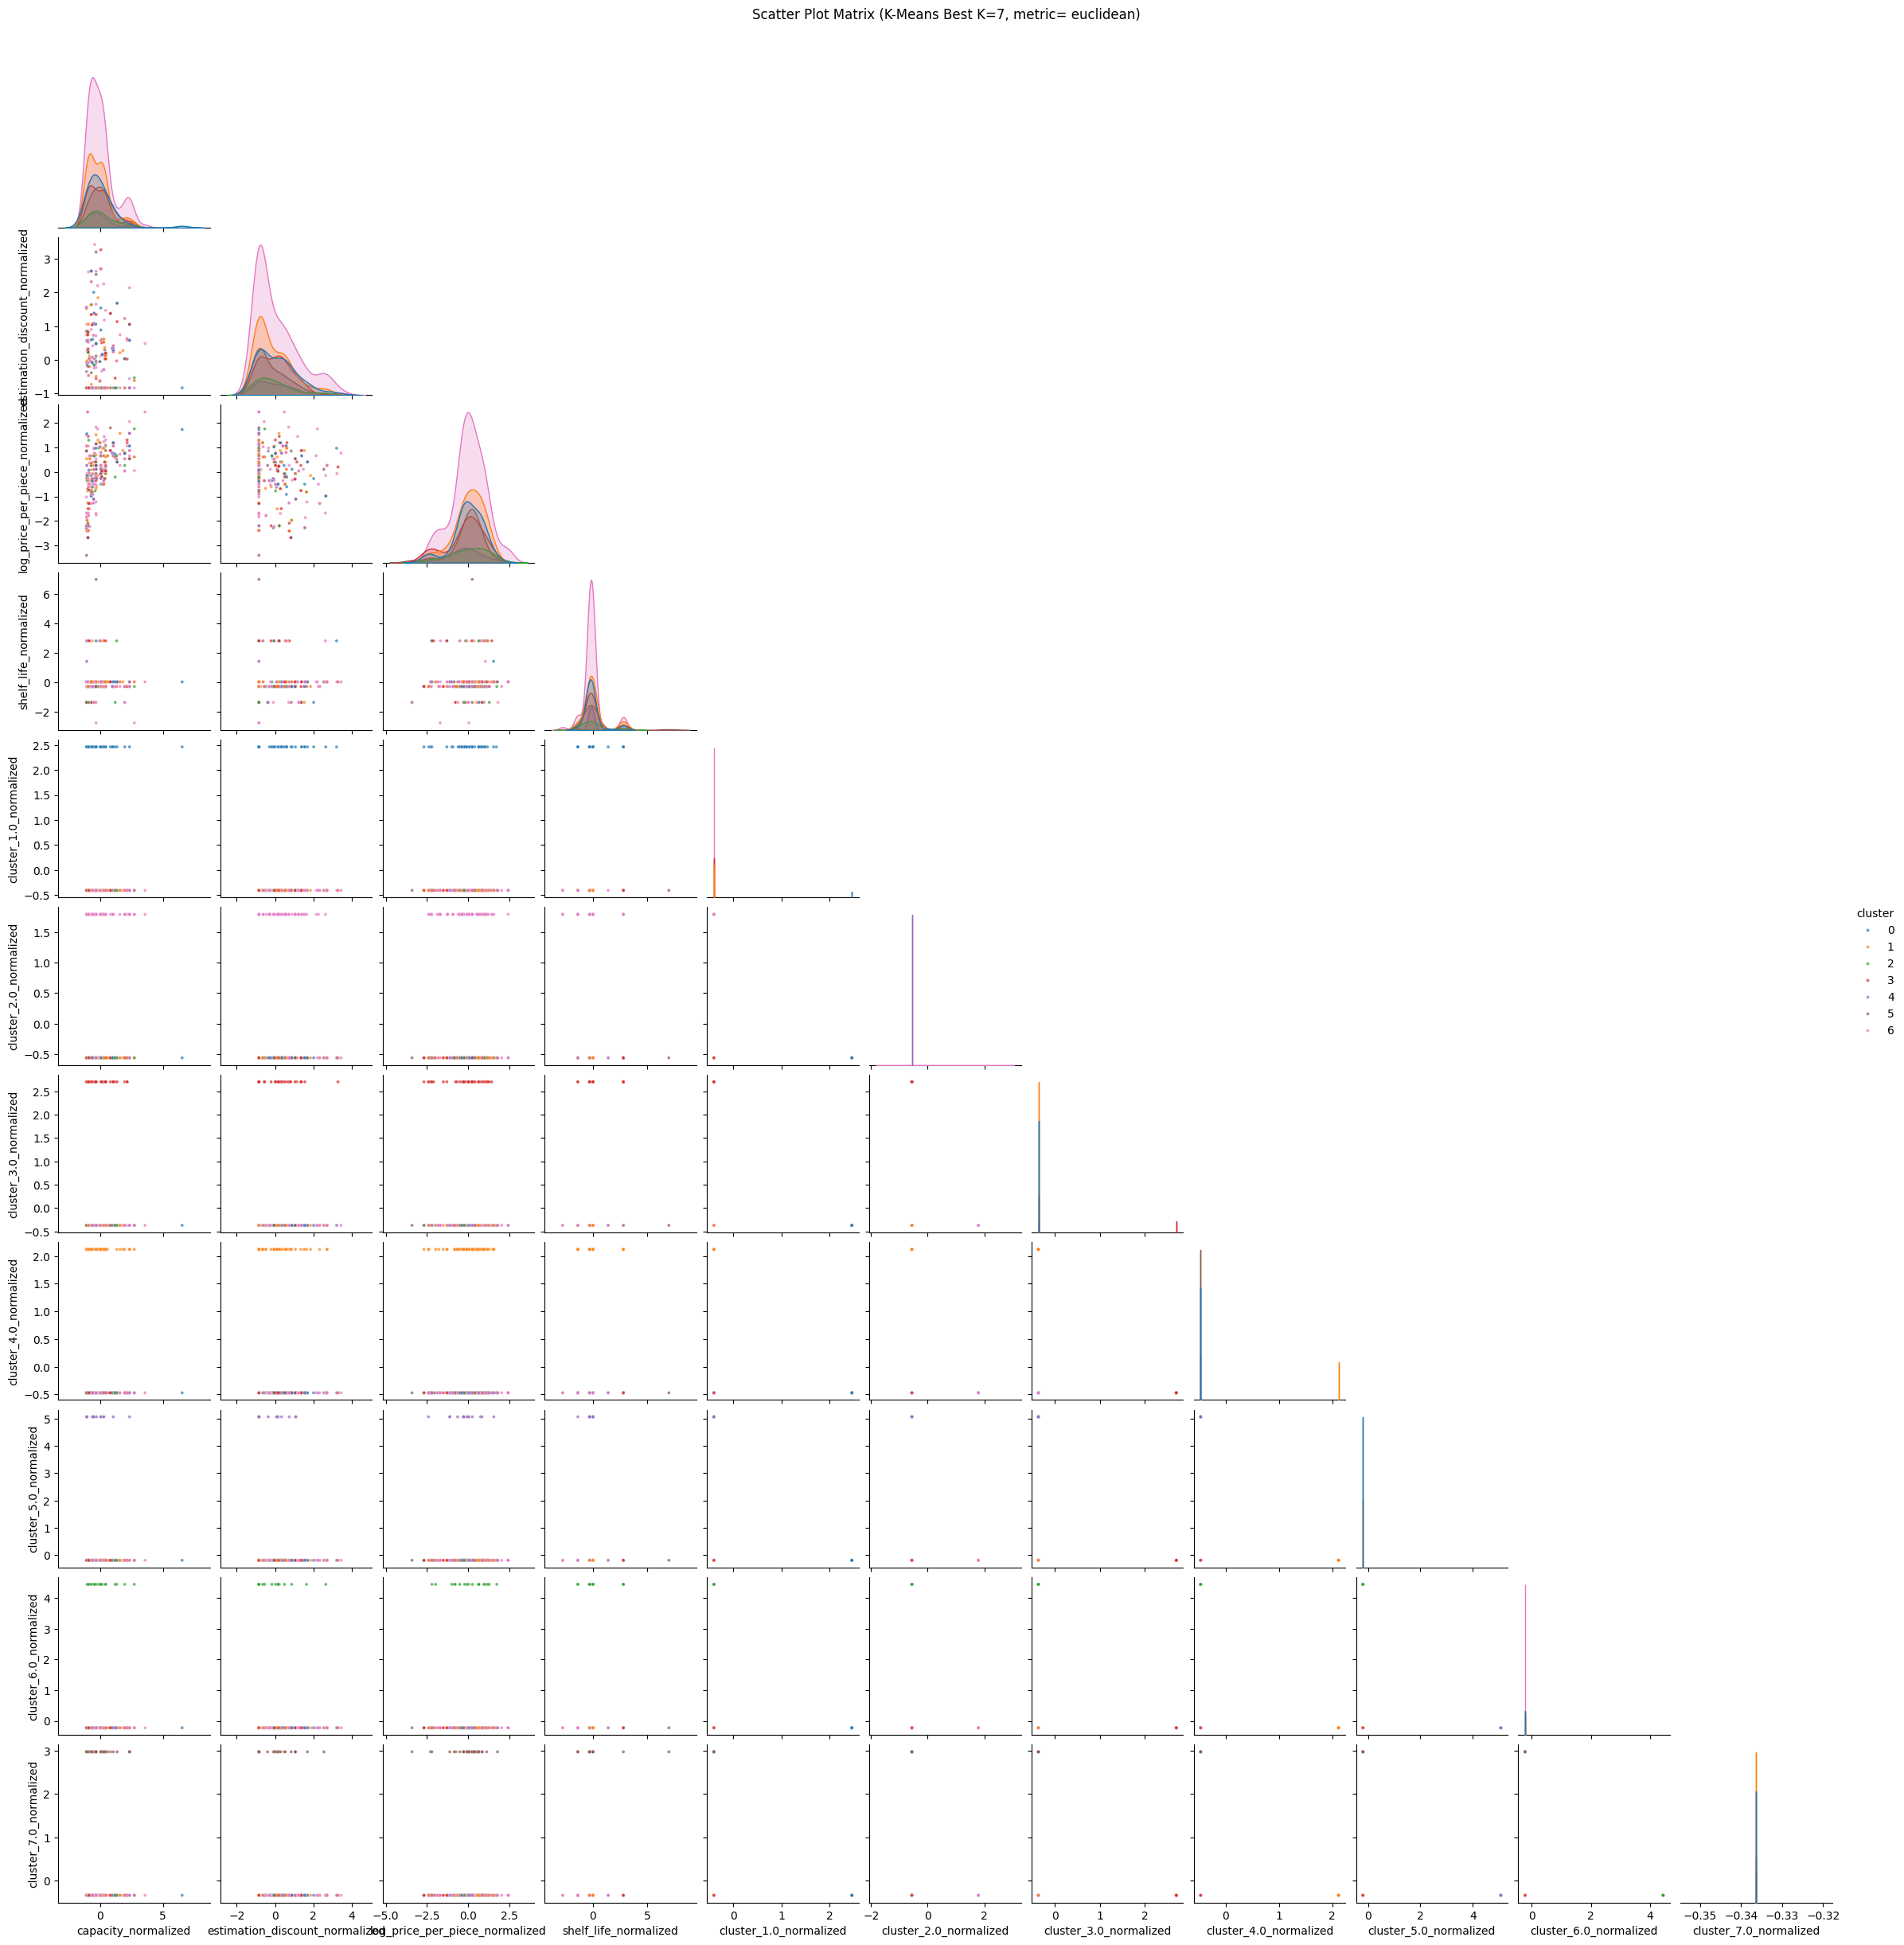

In [20]:
# Scatter Plot Matrix K-Means
def scatterplot_matrix_kmeans_best(df, feature_columns, best_k):
    '''
    Generate a scatter plot matrix for K-Means.
    '''
    g = sns.pairplot(
        data=df,
        vars=feature_columns,
        hue='cluster',
        palette='tab10',
        corner=True,
        plot_kws={'s': 8, 'edgecolor': 'w', 'alpha': 0.7},
    )
    g.fig.set_size_inches(24, 24)
    g.fig.suptitle(
        f'Scatter Plot Matrix (K-Means Best K={best_k}, metric= euclidean)',
        y=1.02
    )
    for ax in g.axes.flatten():
        if ax:
            ax.xaxis.label.set_size(10)
            ax.yaxis.label.set_size(10)
    plt.show()

scatterplot_matrix_kmeans_best(
    cluster_k_best,
    features_final,
    best_k_static,
 )

In [21]:
# Analyze sales patterns of K-means clusters
df_order_filter = df_order[df_order['商品编码'].isin(cluster_k_best['item_code'])].copy()

cluster_map_kmeans = dict(zip(cluster_k_best['item_code'], cluster_k_best['cluster']))
df_order_filter['kmeans_cluster'] = df_order_filter['商品编码'].map(cluster_map_kmeans)

product_week_sales = (
    df_order_filter
    .groupby(['商品编码','week_start','kmeans_cluster'], as_index=False)['sales']
    .sum()
)

weekly_sales_kmeans = (
    product_week_sales
    .groupby(['week_start','kmeans_cluster'])['sales']
    .agg(sum = 'sum', mean='mean', std='std', count='count')
    .reset_index()
)

weekly_sales_kmeans

,week_start,kmeans_cluster,sum,mean,std,count
0,2021-07-27,0,8354.166667,363.224638,469.096309,23
1,2021-07-27,1,13385.983333,382.456667,454.180588,35
2,2021-07-27,2,3675.833333,306.319444,398.822430,12
3,2021-07-27,3,33674.566667,886.172807,1365.810191,38
4,2021-07-27,4,7033.100000,502.364286,386.705170,14
5,2021-07-27,5,6263.000000,368.411765,326.470722,17
6,2021-07-27,6,56132.666667,1145.564626,2293.701623,49
7,2021-08-03,0,15230.666667,371.479675,466.223623,41
8,2021-08-03,1,60217.016667,885.544363,978.286406,68
9,2021-08-03,2,10528.500000,584.916667,646.651357,18


In [22]:
# Compute weekly percentage contribution of each K-means cluster to total sales

weekly_cluster_sales = weekly_sales_kmeans.copy()

weekly_cluster_sales['weekly_total'] = (
    weekly_sales_kmeans
    .groupby('week_start')['mean']
    .transform('sum')
)

# Percentage per week
weekly_cluster_sales['percentage'] = (
    weekly_cluster_sales['mean'] /
    weekly_cluster_sales['weekly_total'] * 100
)

weekly_cluster_sales.sort_values(['week_start', 'percentage'], ascending = False)

,week_start,kmeans_cluster,sum,mean,std,count,weekly_total,percentage
27,2021-08-17,6,217484.666667,2684.995885,4781.462724,81,7296.171029,36.800068
24,2021-08-17,3,71554.700000,1703.683333,2771.933892,42,7296.171029,23.350376
26,2021-08-17,5,43520.116667,1145.266228,1615.316782,38,7296.171029,15.696812
23,2021-08-17,2,15994.166667,888.564815,1660.017280,18,7296.171029,12.178509
25,2021-08-17,4,3336.600000,333.660000,189.978246,10,7296.171029,4.573084
22,2021-08-17,1,8928.466667,288.015054,272.754062,31,7296.171029,3.947482
21,2021-08-17,0,8819.500000,251.985714,314.931153,35,7296.171029,3.453671
20,2021-08-10,6,285029.166667,3518.878601,5501.547986,81,9652.220050,36.456676
17,2021-08-10,3,118180.133333,2626.225185,3853.082240,45,9652.220050,27.208509
16,2021-08-10,2,9759.833333,1084.425926,1313.856064,9,9652.220050,11.234990


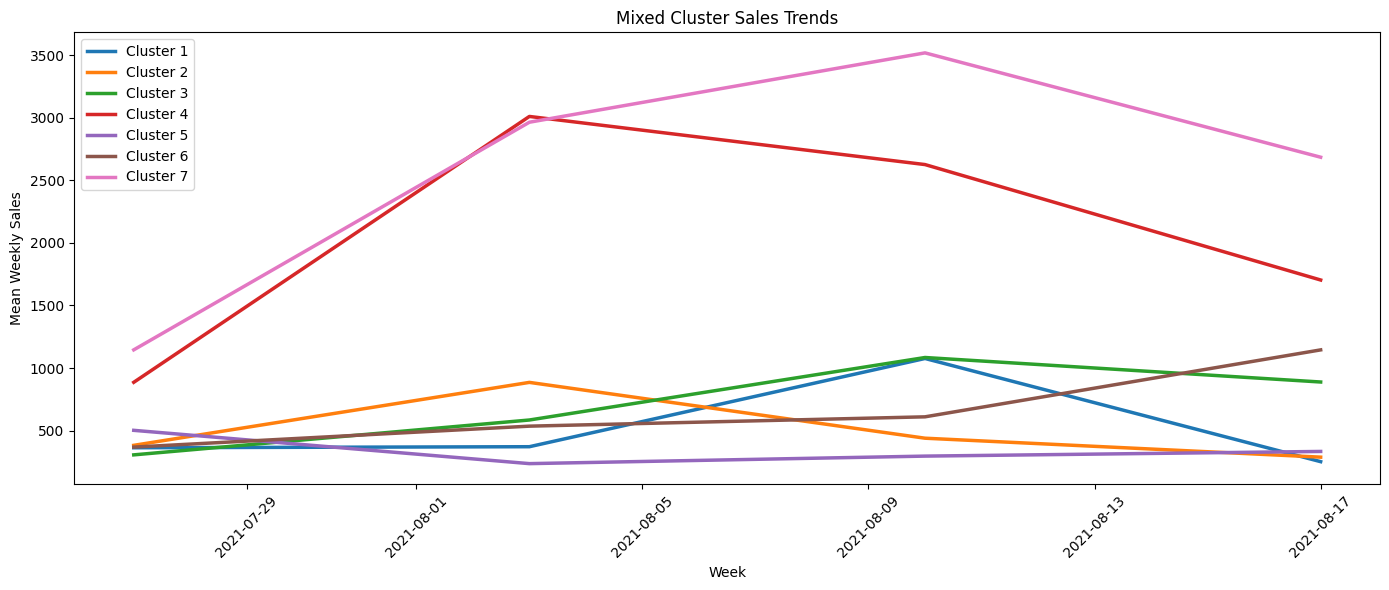

In [23]:
# Visualize the sales time series for each K-means cluster

ts_matrix = ts_wide.drop(columns=['dynamic_cluster'])
weeks = ts_matrix.columns.astype(str)

fig, ax = plt.subplots(figsize=(14,6))

for cluster, data in weekly_sales_kmeans.groupby("kmeans_cluster"):

    data = data.sort_values("week_start")

    x = data["week_start"]
    mean = data["mean"]
    std = data["std"]

    ax.plot(x, mean, linewidth = 2.5, zorder = 2, label=f"Cluster {cluster+1}")

ax.set_title("Mixed Cluster Sales Trends")
ax.set_ylabel("Mean Weekly Sales")
ax.set_xlabel("Week")

plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()

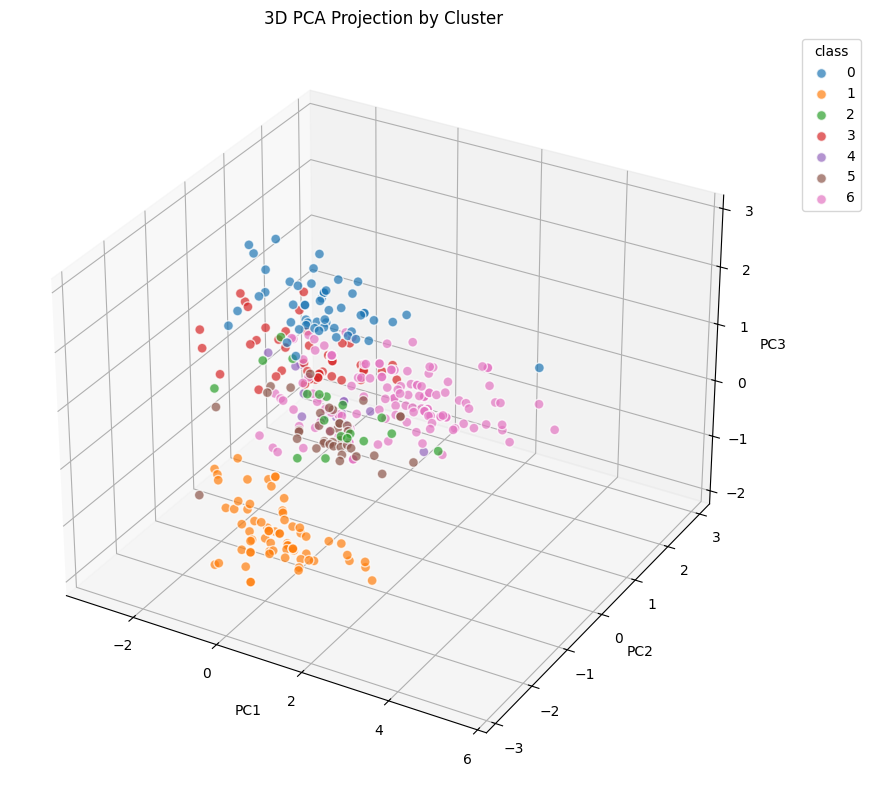

In [24]:
# PCA Projection (3D)
from sklearn.decomposition import PCA

pca = PCA(3)
data_projected = pca.fit_transform(cluster_k_best[features_final])

# Build plotting dataframe with 3 principal components
df_plot = pd.DataFrame({
    'x': data_projected[:, 0],
    'y': data_projected[:, 1],
    'z': data_projected[:, 2],
    'class': cluster_k_best['cluster'].astype(str)
})

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for class_name, group in df_plot.groupby('class'):
    ax.scatter(
        group['x'],
        group['y'],
        group['z'],
        label=class_name,
        s=50,
        alpha=0.7,
        edgecolors='w'
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Projection by Cluster')
ax.legend(title='class', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()